## Task 1: Apply Principal Component Analysis (PCA) for feature extraction and dimensionality reduction
*Suggested Dataset: Iris Dataset*


### Subtask 1.1: Data Acquisition and Feature Standardization
**Concept:** Import warnings suppression and libraries, load the taxonomic Iris dataset, and standardize the feature space using StandardScaler.


In [2]:
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
from sklearn.datasets import load_iris

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
raw_iris = load_iris()

In [9]:
features = raw_iris.feature_names

In [10]:
X_raw = raw_iris.data

In [11]:
y_true = raw_iris.target

In [12]:
scaler = StandardScaler()

In [13]:
X_scaled = scaler.fit_transform(X_raw)

In [14]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [15]:
iris_df['species_id'] = y_true

In [16]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [17]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [18]:
print("Standardized dataset dimensions:", X_scaled.shape)
print("\nFirst 3 rows of standardized dataset:")
print(iris_df.head(3))

Standardized dataset dimensions: (150, 4)

First 3 rows of standardized dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


### Subtask 1.2: Covariance Matrix and Eigenvalue Decomposition
**Concept:** Compute the covariance matrix of the standardized features, then calculate its eigenvalues and eigenvectors to understand PCA's mathematical foundation.


In [19]:
cov_matrix = np.cov(X_scaled.T)

In [20]:
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [21]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [22]:
print("\nEigenvalues (Variance components):\n", eigenvalues)
print("\nEigenvectors (Principal Axes):\n", eigenvectors)


Eigenvalues (Variance components):
 [2.93808505+0.j 0.9201649 +0.j 0.14774182+0.j 0.02085386+0.j]

Eigenvectors (Principal Axes):
 [[ 0.52106591+0.j -0.37741762+0.j -0.71956635+0.j  0.26128628+0.j]
 [-0.26934744+0.j -0.92329566+0.j  0.24438178+0.j -0.12350962+0.j]
 [ 0.5804131 +0.j -0.02449161+0.j  0.14212637+0.j -0.80144925+0.j]
 [ 0.56485654+0.j -0.06694199+0.j  0.63427274+0.j  0.52359713+0.j]]


### Subtask 1.3: Implementing Dimensionality Reduction via PCA
**Concept:** Apply Scikit-Learn's PCA model to project the 4D standardized feature space into 2 principal components.


In [23]:
from sklearn.decomposition import PCA

In [24]:
pca_model = PCA(n_components=2, random_state=42)

In [25]:
X_pca = pca_model.fit_transform(X_scaled)

In [26]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [27]:
pca_df['species_name'] = iris_df['species_name']

In [28]:
print("Transformed PCA space dimensions:", X_pca.shape)
print("\nFirst 3 projected coordinates:")
print(pca_df.head(3))

Transformed PCA space dimensions: (150, 2)

First 3 projected coordinates:
       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


### Subtask 1.4: Visualizing the 2D PCA Feature Space
**Concept:** Plot the projected 2D coordinates on a scatter plot, coloring points by their true species labels to check class separation.


In [29]:
import matplotlib.pyplot as plt

In [30]:
import seaborn as sns

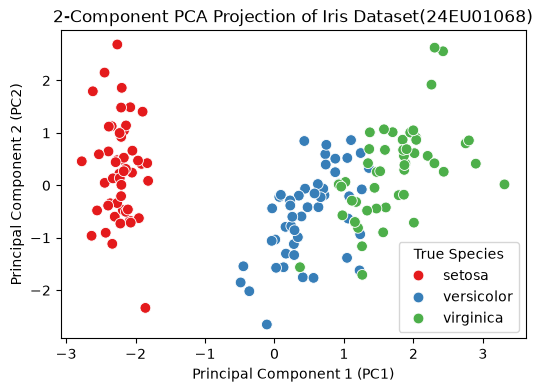

In [76]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset(24EU01068)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

### Subtask 1.5: Analyzing Explained Variance Ratio
**Concept:** Extract and print the explained variance ratio of each principal component to quantify how much information is retained in the 2D projection.


In [32]:
explained_variance = pca_model.explained_variance_ratio_

In [33]:
cumulative_variance = np.sum(explained_variance)

In [34]:
print("Explained Variance per Component:")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Explained Variance per Component:
  PC1: 72.96%
  PC2: 22.85%

Total Cumulative Variance Retained by 2 Components: 95.81%


In [35]:
# ============================================================
# Classification with and without PCA
# Dataset: Iris Dataset
# Classifier: Logistic Regression
# ============================================================

In [36]:
# ============================================================
# PART A: CLASSIFICATION WITHOUT PCA
# ============================================================

In [37]:
import numpy as np

In [38]:
import pandas as pd

In [39]:
import matplotlib.pyplot as plt

In [40]:
from sklearn.datasets import load_iris

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
from sklearn.decomposition import PCA

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [46]:
iris = load_iris()

In [47]:
X = iris.data

In [48]:
y = iris.target

In [49]:
feature_names = iris.feature_names

In [50]:
target_names = iris.target_names

In [51]:
print("Dataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
scaler = StandardScaler()

In [54]:
X_train_scaled = scaler.fit_transform(X_train)

In [55]:
X_test_scaled = scaler.transform(X_test)

In [56]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [57]:
model_without_pca.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [58]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

In [59]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

In [60]:
print("Accuracy without PCA:",
      accuracy_without_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)

Accuracy without PCA: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [61]:
# ============================================================
# PART B: CLASSIFICATION WITH PCA
# ============================================================

In [62]:
pca = PCA(
    n_components=2
)

In [63]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [64]:
X_test_pca = pca.transform(
    X_test_scaled
)

In [65]:
print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())


CLASSIFICATION WITH PCA
Explained Variance Ratio: [0.72677234 0.23066667]
Total Explained Variance: 0.9574390106545363


In [66]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [67]:
model_with_pca.fit(
    X_train_pca,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [68]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

In [69]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

In [70]:
print("Accuracy with PCA:",
      accuracy_with_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)

Accuracy with PCA: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [71]:
# ============================================================
# PART C: COMPARE BOTH MODELS
# ============================================================

In [72]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

In [73]:
print("\n========================================")
print("COMPARISON")
print("========================================")
print(comparison)


COMPARISON
        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


In [74]:
# ============================================================
# PART D: VISUALIZE PCA FEATURES
# ============================================================

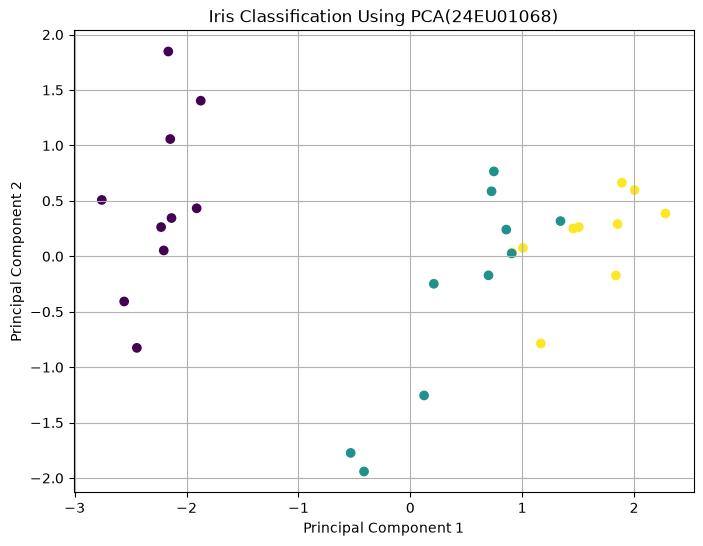

In [77]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA(24EU01068)")
plt.grid()

plt.show()